# 05 · Разбор матча: что не так с гранатами у каждого игрока

Логика — `src/report.py`: `match_report(match_id)` → сводка по 10 игрокам + список проблем.

| Проблема | Как определяем | Вес |
|---|---|---|
| **вредная флешка** | ослепила своих > 1.5 с, врагов — никого | 1 + 0.3 за каждого ослеплённого своего |
| **смерть своего от флешки** | тиммейт убит, пока был ослеплён флешкой игрока | 2 |
| **промах: техника** | промах раскидки, техника (прыжок) не совпадает с нормой | 2 |
| **промах раскидки** | промах раскидки с hit_rate ≥ 60% (флешки не учитываем) | 1 |
| **плохая раскидка** | с той же позиции есть заметно лучшая альтернатива | 1.5 |
| **раунды без гранат** | закуп команды (6+ гранат), игрок — 0 | 0.5 за раунд |

**Ошибки** vs **подсказки** — см. раздел 6. Нормы пересчитываются без анализируемого матча.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from report import load_data, match_report, player_teams
from mapviz import draw_map

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 160)
plt.rcParams.update({"figure.dpi": 90})

data = load_data()
throws = data["th"]
flash_victims = data["fv"]
lineups = data["cat"]
sample_matches = throws.match_id.drop_duplicates().sample(3, random_state=7).tolist()
sample_matches

[3831204372419707450, 3830868110840168516, 3830636592775561399]

## 1. Визуализация проблем на карте

In [2]:
def arrow(ax, x0, y0, x1, y1, color, ls="-", lw=2):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="->", color=color, lw=lw, ls=ls))


def lineup_arrow(ax, lineup_id, color, ls="--"):
    ref = lineups.loc[lineup_id]
    arrow(ax, ref.throw_cx, ref.throw_cy, ref.land_cx, ref.land_cy, color, ls)


def plot_problem(ax, problem):
    throw = throws[throws.grenade_id == problem.grenade_id].iloc[0] if pd.notna(problem.grenade_id) else None
    draw_map(ax, alpha=0.6)
    if throw is not None:
        arrow(ax, throw.throw_x, throw.throw_y, throw.land_x, throw.land_y, "red")
    if problem.kind in ("вредная флешка", "смерть своего от флешки"):
        victims = flash_victims[flash_victims.grenade_id == problem.grenade_id]
        for victim in victims.itertuples():
            color = "lime" if victim.victim == "enemy" else "red"
            ax.scatter(victim.pos_x, victim.pos_y, s=60, color=color, edgecolor="black", zorder=5)
            ax.text(
                victim.pos_x + 30,
                victim.pos_y,
                f"{victim.victim} {victim.duration:.1f}с" + (" †" if victim.killed else ""),
                color="white",
                fontsize=8,
                bbox=dict(fc="black", alpha=0.6, lw=0),
            )
    elif problem.kind.startswith("промах"):
        lineup_arrow(ax, problem.lineup_id, "lime")
    elif problem.kind == "плохая раскидка":
        lineup_arrow(ax, problem.lineup_id, "orange")
        lineup_arrow(ax, problem.alt_id, "deepskyblue")
    if throw is not None:
        xs = [throw.throw_x, throw.land_x]
        ys = [throw.throw_y, throw.land_y]
        ax.set_xlim(min(xs) - 600, max(xs) + 600)
        ax.set_ylim(min(ys) - 600, max(ys) + 600)
    ax.set_title(f"раунд {problem.round + 1} · {problem.kind}", fontsize=10)


def show_player(player_id, problems, top_k=4):
    top = problems[(problems.player_id == player_id) & problems.grenade_id.notna()].sort_values(
        "weight", ascending=False
    ).head(top_k)
    if top.empty:
        return
    fig, axs = plt.subplots(1, len(top), figsize=(6 * len(top), 5.5), squeeze=False)
    for ax, row in zip(axs[0], top.itertuples()):
        plot_problem(ax, row)
    plt.tight_layout()
    plt.show()


def show_match(match_id):
    summary, problems = match_report(match_id, data)
    n_rounds = throws.loc[throws.match_id == match_id, "round"].nunique()
    print(f"матч {match_id}: {n_rounds} раундов")
    display(summary.round(1))
    display(problems.pivot_table(index="player_id", columns="kind", values="weight", aggfunc="size", fill_value=0))
    return summary, problems

## 2. Матч 1

In [3]:
summary_0, problems_0 = show_match(sample_matches[0])

матч 3831204372419707450: 17 раундов


,team,rating,гранат,smoke,flash,he,fire,гранат/раунд,флешки: полезных,флешки: вредных,врагов ослеплено,своих ослеплено,урон HE+огонь,раскидок,попаданий %,ошибок,вес ошибок,подсказок
player_id,,,,,,,,,,,,,,,,,,
119769136,A,<NA>,29,9,14,4,2,1.7,7,3,10.0,4.0,83.0,14,71.428571,4.0,5.2,0.0
1201685842,A,20106,28,6,8,7,7,1.6,2,3,6.0,3.0,211.0,15,73.333333,3.0,3.9,1.0
120142393,A,10119,40,13,11,7,9,2.4,1,1,4.0,3.0,83.0,13,84.615385,2.0,2.3,1.0
92254611,A,<NA>,29,7,10,6,6,1.7,2,0,2.0,0.0,103.0,21,76.190476,2.0,2.0,2.0
1636141658,A,13689,18,3,8,5,2,1.1,7,0,13.0,0.0,28.0,5,20.0,0.0,0.0,1.0
242465421,B,<NA>,27,8,13,5,1,1.6,3,2,8.0,6.0,20.0,12,66.666667,3.0,3.6,2.0
255929484,B,<NA>,32,10,5,12,5,1.9,0,0,0.0,0.0,107.0,18,77.777778,2.0,2.0,0.0
103365326,B,<NA>,19,5,3,4,7,1.1,1,0,5.0,0.0,126.0,16,87.5,2.0,2.0,4.0
150478345,B,16556,4,1,1,1,1,0.2,0,0,0.0,0.0,0.0,3,66.666667,0.0,0.0,1.0


kind,вредная флешка,плохая раскидка,промах раскидки,раунды без гранат,смерть своего от флешки
player_id,,,,,
92254611,0,1,2,1,0
103365326,0,3,2,1,0
119769136,3,0,1,0,0
120142393,1,1,1,0,0
150478345,0,0,0,1,0
242465421,2,1,1,0,1
255929484,0,0,2,0,0
1201685842,3,0,0,1,0
1636141658,0,0,0,1,0


игрок 119769136


,round,category,kind,text,weight
6,5,ошибка,вредная флешка,"флешка ослепила только своих: себя 2.4с, тиммейта 1.7с; врагов дольше 1.5 с — никого",1.6
2,6,ошибка,вредная флешка,флешка ослепила только своих: тиммейта 2.5с; врагов дольше 1.5 с — никого,1.3
9,15,ошибка,вредная флешка,флешка ослепила только своих: тиммейта 3.0с; врагов дольше 1.5 с — никого,1.3
10,10,ошибка,промах раскидки,smoke-T-059 упал в 439 ед. от нормы (попадают 68%),1.0


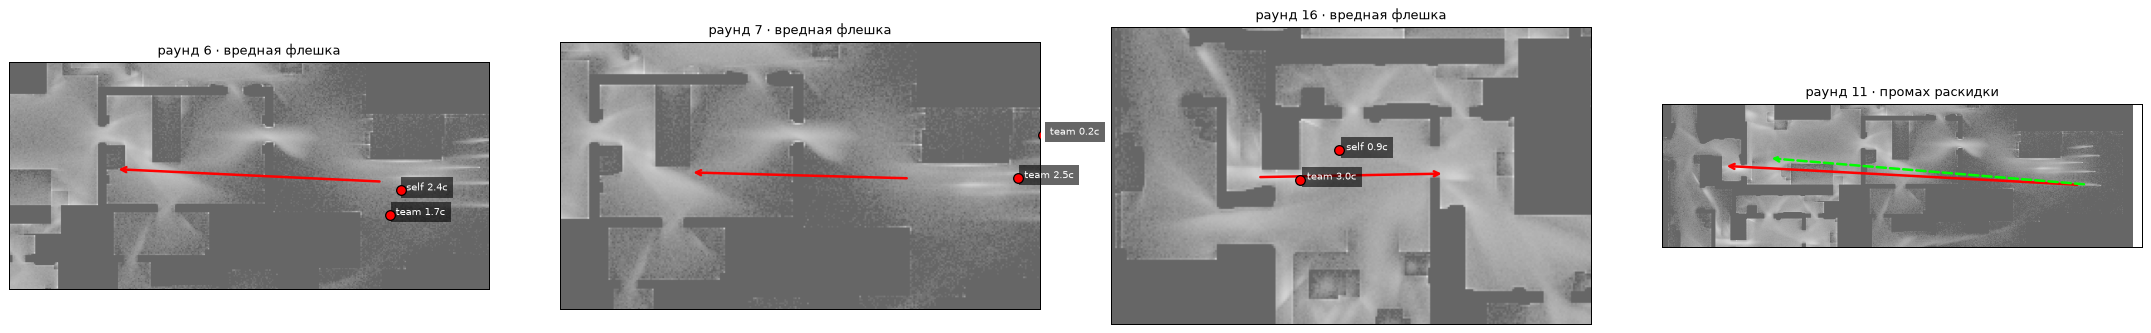

In [4]:
worst_player = summary_0["вес ошибок"].idxmax()
print("игрок", worst_player)
display(
    problems_0[problems_0.player_id == worst_player]
    .sort_values(["category", "weight"], ascending=[True, False])[["round", "category", "kind", "text", "weight"]]
    .head(6)
)
show_player(worst_player, problems_0)

## 3. Матч 2

In [5]:
summary_1, problems_1 = show_match(sample_matches[1])

матч 3830868110840168516: 19 раундов


,team,rating,гранат,smoke,flash,he,fire,гранат/раунд,флешки: полезных,флешки: вредных,врагов ослеплено,своих ослеплено,урон HE+огонь,раскидок,попаданий %,ошибок,вес ошибок,подсказок
player_id,,,,,,,,,,,,,,,,,,
217941477,A,<NA>,23,3.0,4.0,8.0,8,1.2,2,0,3.0,0.0,78.0,10,30.0,3.0,3.0,1.0
794292384,A,6893,33,11.0,3.0,12.0,7,1.7,0,1,1.0,2.0,135.0,13,53.846154,2.0,2.3,2.0
815026411,A,<NA>,22,9.0,7.0,3.0,3,1.2,4,1,6.0,1.0,27.0,17,70.588235,2.0,2.3,2.0
1095279380,A,<NA>,16,6.0,5.0,3.0,2,0.8,2,0,4.0,0.0,33.0,11,63.636364,2.0,2.0,1.0
152256528,A,<NA>,4,0.0,0.0,2.0,2,0.2,0,0,0.0,0.0,0.0,1,0.0,0.0,0.0,1.0
1010905066,B,<NA>,8,1.0,4.0,1.0,2,0.4,1,3,1.0,11.0,0.0,2,100.0,3.0,6.3,1.0
1284802870,B,6620,6,2.0,0.0,0.0,4,0.3,0,0,0.0,0.0,0.0,3,0.0,3.0,3.0,0.0
436660637,B,<NA>,10,0.0,0.0,7.0,3,0.5,0,0,0.0,0.0,108.0,6,33.333333,2.0,2.0,0.0
1876431779,B,<NA>,8,2.0,3.0,2.0,1,0.4,0,1,0.0,1.0,7.0,3,66.666667,1.0,1.3,0.0


kind,вредная флешка,плохая раскидка,промах раскидки,раунды без гранат,смерть своего от флешки
player_id,,,,,
152256528,0,0,0,1,0
217941477,0,0,3,1,0
436660637,0,0,2,0,0
794292384,1,2,1,0,0
815026411,1,1,1,1,0
1010905066,3,0,0,1,0
1058451118,0,0,0,0,1
1095279380,0,0,2,1,0
1284802870,0,0,3,0,0


игрок 1010905066


,round,category,kind,text,weight
4,18,ошибка,вредная флешка,"флешка ослепила только своих: тиммейта 4.4с, тиммейта 4.2с, тиммейта 3.5с, себя 4.1с, тиммейта 4.0с; врагов дольше 1.5 с — никого",2.5
2,19,ошибка,вредная флешка,"флешка ослепила только своих: тиммейта 4.7с, тиммейта 4.7с, тиммейта 2.0с, себя 4.6с, тиммейта 4.7с; врагов дольше 1.5 с — никого",2.5
1,7,ошибка,вредная флешка,флешка ослепила только своих: тиммейта 3.4с; врагов дольше 1.5 с — никого,1.3
23,14,подсказка,раунды без гранат,"1 из 3 раундов, где команда кинула 6+ гранат, ты не кинул ни одной (раунды 15; возможно, погиб раньше)",0.5


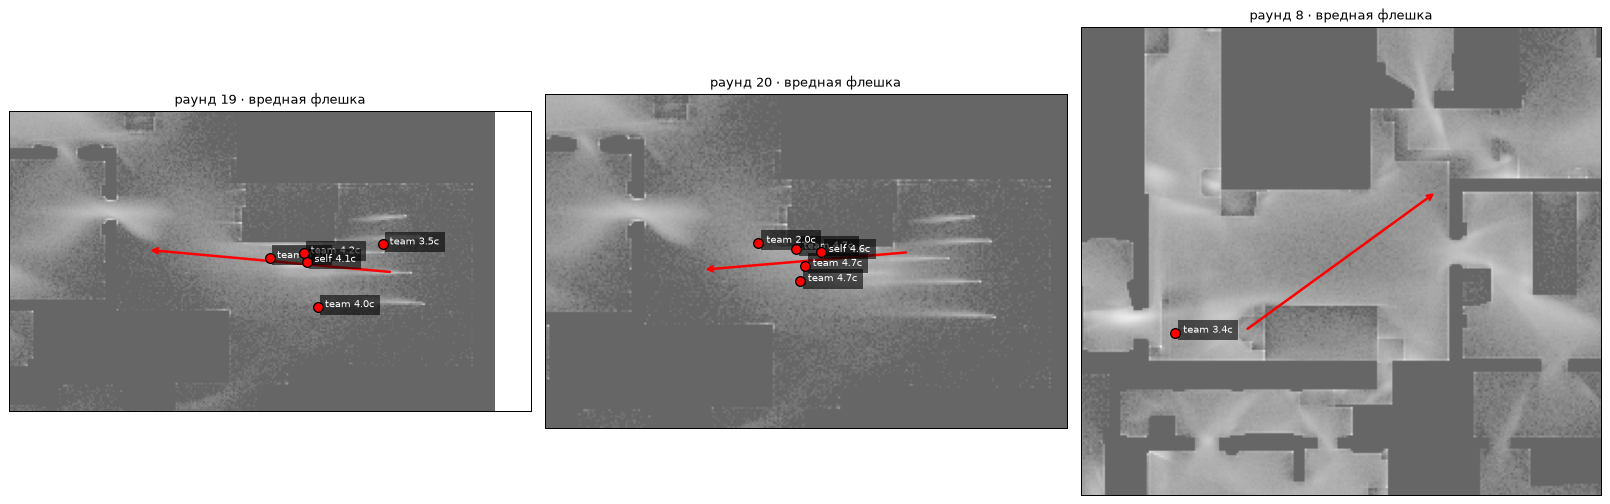

In [6]:
worst_player = summary_1["вес ошибок"].idxmax()
print("игрок", worst_player)
display(
    problems_1[problems_1.player_id == worst_player]
    .sort_values(["category", "weight"], ascending=[True, False])[["round", "category", "kind", "text", "weight"]]
    .head(6)
)
show_player(worst_player, problems_1)

## 4. Матч 3

In [7]:
summary_2, problems_2 = show_match(sample_matches[2])

матч 3830636592775561399: 17 раундов


,team,rating,гранат,smoke,flash,he,fire,гранат/раунд,флешки: полезных,флешки: вредных,врагов ослеплено,своих ослеплено,урон HE+огонь,раскидок,попаданий %,ошибок,вес ошибок,подсказок
player_id,,,,,,,,,,,,,,,,,,
360183719,A,<NA>,27,8.0,9.0,7,3.0,1.6,2,4,3.0,5.0,100.0,14,57.142857,8.0,9.2,4
13660035,A,<NA>,12,2.0,6.0,4,0.0,0.7,2,2,4.0,3.0,146.0,8,100.0,2.0,2.6,1
197811018,A,<NA>,24,8.0,5.0,6,5.0,1.4,1,1,2.0,2.0,45.0,17,88.235294,1.0,1.3,2
40329507,A,<NA>,15,5.0,5.0,4,1.0,0.9,1,0,2.0,1.0,6.0,11,81.818182,1.0,1.0,2
115423351,A,<NA>,2,0.0,0.0,2,0.0,0.1,0,0,0.0,0.0,55.0,1,100.0,0.0,0.0,2
1715797585,B,<NA>,33,9.0,11.0,6,7.0,1.9,4,2,7.0,2.0,169.0,18,83.333333,3.0,3.6,1
1767619727,B,<NA>,19,6.0,7.0,4,2.0,1.1,2,2,4.0,4.0,22.0,8,87.5,3.0,3.6,2
189221584,B,9624,16,1.0,3.0,10,2.0,0.9,0,0,1.0,1.0,120.0,10,90.0,1.0,1.0,1
86514765,B,<NA>,28,11.0,4.0,7,6.0,1.6,2,0,6.0,2.0,60.0,27,85.185185,0.0,0.0,2


kind,вредная флешка,плохая раскидка,промах раскидки,раунды без гранат,смерть своего от флешки
player_id,,,,,
13660035,2,0,0,1,0
40329507,0,1,1,1,0
86514765,0,2,0,0,0
115423351,0,1,0,1,0
189221584,0,0,1,1,0
197811018,1,2,0,0,0
360183719,4,2,4,1,1
1128431286,0,0,0,1,0
1715797585,2,1,1,0,0


игрок 360183719


,round,category,kind,text,weight
6,5,ошибка,вредная флешка,флешка ослепила только своих: тиммейта 1.9с; врагов дольше 1.5 с — никого,1.3
11,5,ошибка,вредная флешка,флешка ослепила только своих: тиммейта 1.6с; врагов дольше 1.5 с — никого,1.3
8,9,ошибка,вредная флешка,флешка ослепила только своих: тиммейта 5.2с; врагов дольше 1.5 с — никого,1.3
1,10,ошибка,вредная флешка,флешка ослепила только своих: тиммейта 4.5с; врагов дольше 1.5 с — никого,1.3
14,5,ошибка,промах раскидки,he-T-139 упал в 496 ед. от нормы (попадают 70%),1.0
13,11,ошибка,промах раскидки,smoke-T-010 упал в 964 ед. от нормы (попадают 90%),1.0


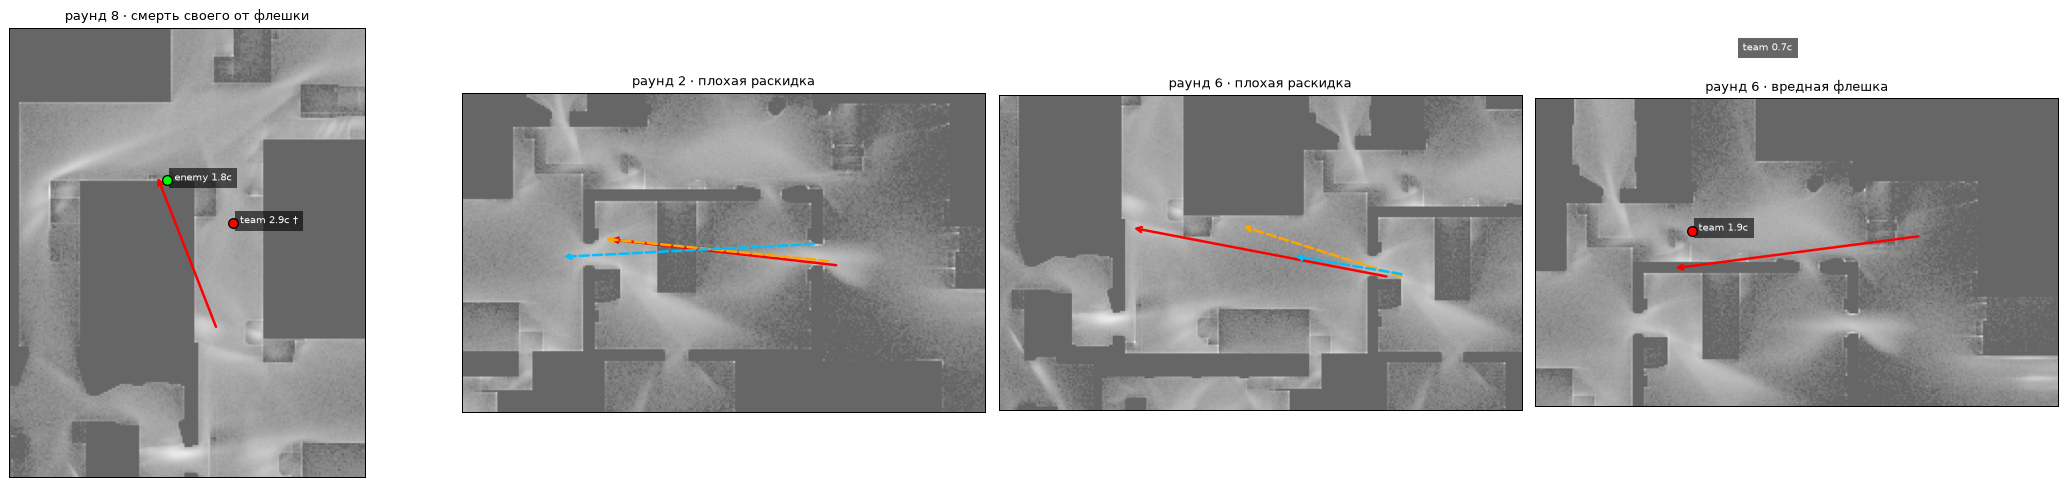

In [8]:
worst_player = summary_2["вес ошибок"].idxmax()
print("игрок", worst_player)
display(
    problems_2[problems_2.player_id == worst_player]
    .sort_values(["category", "weight"], ascending=[True, False])[["round", "category", "kind", "text", "weight"]]
    .head(6)
)
show_player(worst_player, problems_2)

## 5. Ручная проверка событий

In [9]:
all_problems = pd.concat([problems_0, problems_1, problems_2])
flash_example = all_problems[all_problems.kind == "вредная флешка"].iloc[0]
print(flash_example.text)
flash_victims[flash_victims.grenade_id == flash_example.grenade_id][
    ["player_id", "side", "victim", "duration", "killed", "killed_by"]
]

флешка ослепила только своих: себя 2.4с, тиммейта 1.7с; врагов дольше 1.5 с — никого


,player_id,side,victim,duration,killed,killed_by
316238,119769136,T,self,2.361967,False,<NA>
316239,92254611,T,team,1.707591,False,<NA>


Сверка промаха по технике: прыжок игрока vs норма раскидки.

In [10]:
miss_example = all_problems[all_problems.kind.str.startswith("промах")].sort_values("weight", ascending=False).iloc[0]
print(miss_example.text)
throw_row = throws[throws.grenade_id == miss_example.grenade_id][
    ["round", "type", "airborne", "crouch", "intent_id", "hit", "land_dev", "throw_dist", "aim_dev"]
]
display(throw_row)
lineups.loc[[miss_example.lineup_id], ["n", "airborne", "land_spread", "throw_spread"]]

fire-T-079 упал в 169 ед. от нормы (попадают 82%)


,round,type,airborne,crouch,intent_id,hit,land_dev,throw_dist,aim_dev
755850,5,fire,False,False,fire-T-079,False,169.127045,36.433456,0.556165


,n,airborne,land_spread,throw_spread
lineup_id,,,,
fire-T-079,380,0.002632,38.883031,57.14886


Раунды без гранат: сколько кинул каждый игрок команды в отмеченных раундах.

In [11]:
match_id = sample_matches[0]
teams = player_teams(match_id, data)
match_throws = throws[throws.match_id == match_id].assign(team=lambda df: df.thrower_id.map(teams))
match_throws.pivot_table(
    index=["team", "thrower_id"], columns="round", values="grenade_id", aggfunc="size", fill_value=0
)

round            1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17
team thrower_id                                                                    
A    92254611     2   0   5   0   4   2   0   2   0   3   2   0   1   3   4   0   1
     119769136    2   0   2   2   4   3   0   2   1   3   3   2   0   2   2   0   1
     120142393    3   0   4   3   3   1   0   4   3   3   3   0   0   4   4   3   2
     1201685842   0   1   0   1   3   0   2   1   4   4   2   2   1   0   2   2   3
     1636141658   0   0   0   2   2   1   1   4   2   1   1   0   0   0   1   0   3
B    103365326    0   2   1   3   1   0   2   3   1   2   1   0   3   0   0   0   0
     150478345    1   0   0   0   0   2   0   0   0   0   0   0   1   0   0   0   0
     242465421    0   3   1   3   0   4   2   2   0   1   3   0   1   0   2   2   3
     255929484    2   3   4   4   2   5   1   1   0   1   2   0   1   0   0   2   4
     1793545178   1   1   0   0   0   0   4   2   0   0   3   0   0   0   2   0   0

## 6. Как часто встречаются проблемы (200 случайных матчей)

In [12]:
sample_match_ids = throws.match_id.drop_duplicates().sample(200, random_state=0)
summaries, all_probs = [], []
for match_id in sample_match_ids:
    summary, probs = match_report(match_id, data)
    summaries.append(summary.assign(match_id=match_id))
    all_probs.append(probs.assign(match_id=match_id))
summaries_df = pd.concat(summaries)
problems_sample = pd.concat(all_probs, ignore_index=True)
n_players = len(summaries_df)
per_kind = pd.DataFrame(
    {
        "событий": problems_sample.groupby("kind").size(),
        "игроков": problems_sample.drop_duplicates(["kind", "match_id", "player_id"]).groupby("kind").size(),
    }
)
per_kind["событий на игрока"] = per_kind["событий"] / n_players
per_kind["% игроков с проблемой"] = per_kind["игроков"] / n_players * 100
per_kind.round(2).sort_values("% игроков с проблемой", ascending=False)

,событий,игроков,событий на игрока,% игроков с проблемой
kind,,,,
раунды без гранат,1415,1415,0.71,70.79
промах раскидки,2434,1229,1.22,61.48
вредная флешка,2319,1116,1.16,55.83
плохая раскидка,1463,876,0.73,43.82
смерть своего от флешки,324,280,0.16,14.01
промах: техника,34,32,0.02,1.60


игроков без ошибок: 20.2%; медиана ошибок: 2; без проблем вообще: 4.0%


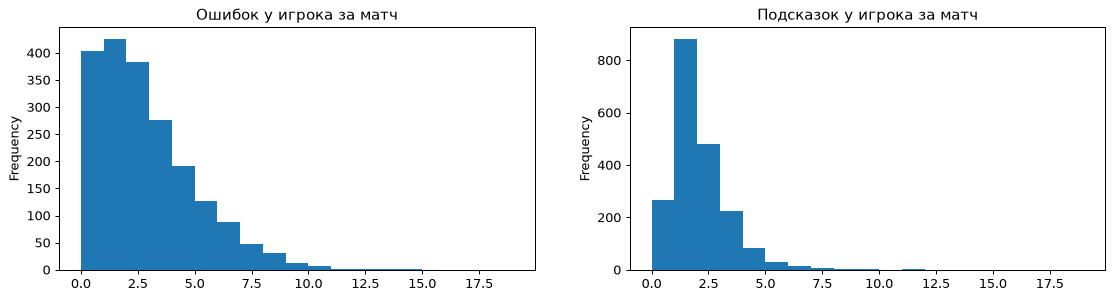

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(15, 3.5))
summaries_df["ошибок"].plot.hist(bins=range(0, 20), ax=axs[0], title="Ошибок у игрока за матч")
summaries_df["подсказок"].plot.hist(bins=range(0, 20), ax=axs[1], title="Подсказок у игрока за матч")
print(
    f"игроков без ошибок: {(summaries_df['ошибок'] == 0).mean():.1%}; медиана ошибок: {summaries_df['ошибок'].median():.0f}; "
    f"без проблем вообще: {((summaries_df['ошибок'] + summaries_df['подсказок']) == 0).mean():.1%}"
)

## 6. Связь с рейтингом (400 матчей, на гранату)

In [14]:
rated_match_ids = throws[throws.rating.notna()].match_id.drop_duplicates().sample(400, random_state=0)
rated_rows = []
for match_id in rated_match_ids:
    summary, probs = match_report(match_id, data)
    counts = probs.groupby(["player_id", "kind"]).size().unstack()
    rated_rows.append(summary.join(counts).assign(match_id=match_id))
rated_df = pd.concat(rated_rows)
rated_df = rated_df[rated_df.rating.notna()].fillna({kind: 0 for kind in problems_sample.kind.unique()})
rated_df["tier"] = pd.cut(
    rated_df.rating.astype(float),
    [0, 10000, 15000, 20000, np.inf],
    labels=["<10k", "10-15k", "15-20k", "20k+"],
    right=False,
)
rated_df["rounds"] = rated_df.match_id.map(throws.groupby("match_id")["round"].nunique())
by_tier = rated_df.groupby("tier", observed=True)
pd.DataFrame(
    {
        "игроков": by_tier.size(),
        "гранат/раунд": by_tier.apply(lambda x: (x["гранат"] / x.rounds).mean()),
        "вредных флешек / 10 флешек": by_tier["вредная флешка"].sum() / by_tier["flash"].sum() * 10,
        "смертей своих / 100 флешек": by_tier["смерть своего от флешки"].sum() / by_tier["flash"].sum() * 100,
        "промахов / 10 гранат": (by_tier["промах раскидки"].sum() + by_tier["промах: техника"].sum()) / by_tier["гранат"].sum() * 10,
        "плохих раскидок / 10 гранат": by_tier["плохая раскидка"].sum() / by_tier["гранат"].sum() * 10,
        "% игроков с раундами без гранат": by_tier["раунды без гранат"].apply(lambda x: (x > 0).mean() * 100),
    }
).round(2)

,игроков,гранат/раунд,вредных флешек / 10 флешек,смертей своих / 100 флешек,промахов / 10 гранат,плохих раскидок / 10 гранат,% игроков с раундами без гранат
tier,,,,,,,
<10k,311,0.97,1.92,2.15,0.60,0.32,66.88
10-15k,306,1.20,1.70,2.45,0.56,0.36,68.30
15-20k,352,1.29,1.70,2.53,0.52,0.27,74.15
20k+,244,1.37,1.48,2.79,0.52,0.29,72.54


## 7. Почему нет оценки «твой уровень ~Xk» по одному матчу

Разброс доли попаданий **между матчами одного и того же уровня** гораздо больше, чем разница между уровнями.

In [15]:
intent_rated = throws[throws.intent_id.notna() & throws.rating_tier.notna()]
per_match_player = intent_rated.groupby(["match_id", "thrower_id", "rating_tier"], observed=True).hit.agg(["mean", "size"])
per_match_player = per_match_player[per_match_player["size"] >= 5]
level_spread = per_match_player.groupby("rating_tier", observed=True)["mean"].agg(["mean", "std"]).mul(100).round(1)
level_spread.columns = ["средний % попаданий", "разброс по матчам (std)"]
level_spread

,средний % попаданий,разброс по матчам (std)
rating_tier,,
<5k,69.169028,16.7
5-10k,71.221201,15.9
10-15k,73.447191,14.9
15-20k,75.904928,13.7
20-25k,77.757624,13.0
25k+,77.802559,13.8


Разброс по матчам ~15–20 п.п., а разница между крайними уровнями ~9 п.п. → по одному матчу уровень не определить; это возможно только по истории игрока.

## Выводы

1. **Отчёт по матчу работает на любом матче** без истории игрока: сводка по 10 игрокам + конкретные события
   с раундом и картинкой. Расчёт — ~0.6 с на матч.
2. **Ручная проверка** событий против исходных таблиц сходится (ослеплённые, длительности, прыжок, раунды без гранат).
3. **Проблемы есть почти у всех:** у 96% игроков хотя бы одна, медиана — 3 за матч. Самые частые: раунды без гранат (71% игроков),
   промахи раскидок (61%), вредные флешки (56%).
4. **Какие сигналы отражают навык** (на гранату, от <10k к 20k+):
   - ✅ **вредные флешки** 1.9 → 1.5 на 10 флешек и ✅ **промахи раскидок** 0.60 → 0.52 на 10 гранат — падают с рейтингом;
   - ⚠️ **плохая раскидка** — без тренда: выбор раскидки скорее тактика, чем навык → подавать как подсказку, а не ошибку;
   - ❌ **смерть своего от флешки** растёт с рейтингом (сильные агрессивнее флешат под заход) и ❌ **раунды без гранат** —
     смещение: у сильных команда чаще кидает 6+ гранат, проверок больше. Это скорее наблюдения, чем ошибки.
5. **Уровень «~Xk» по одному матчу не определить:** разброс доли попаданий между матчами (13–17 п.п.) больше разницы между уровнями (~9 п.п.).
6. **Граничные случаи:** флешка, ослепившая 4 своих и себя на 4+ с, — возможно, брошена после конца раунда или «в шутку»;
   времени конца раунда в данных нет, отфильтровать нельзя.